<a href="https://colab.research.google.com/github/vifirsanova/ML-2026-pt-2/blob/main/beginners/rnn_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация текстов с помощью RNN (PyTorch)

- загрузка и визуализация данных;
- токенизация и словарь;
- RNN-классификатор;
- обучение, кривые, матрица ошибок;
- задания с плейсхолдерами для изменения гиперпараметров.

## 1. Окружение

In [1]:
!pip install -q datasets scikit-learn seaborn tqdm matplotlib

In [2]:
import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence
)

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"Using device: {device}")

Using device: cuda


## 2. Загрузка данных

In [4]:
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)
print("\nПример:", dataset['train'][0])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Пример: {'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [5]:
train_data = list(zip(
    dataset['train']['label'],
    dataset['train']['text']
))

test_data = list(zip(
    dataset['test']['label'],
    dataset['test']['text']
))

print(f"Обучающих примеров: {len(train_data)}")
print(f"Тестовых примеров: {len(test_data)}")

print(
    f"\nРаспределение меток: "
    f"{Counter(label for label, _ in train_data)}"
)

Обучающих примеров: 120000
Тестовых примеров: 7600

Распределение меток: Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})


## 3. Визуализация данных

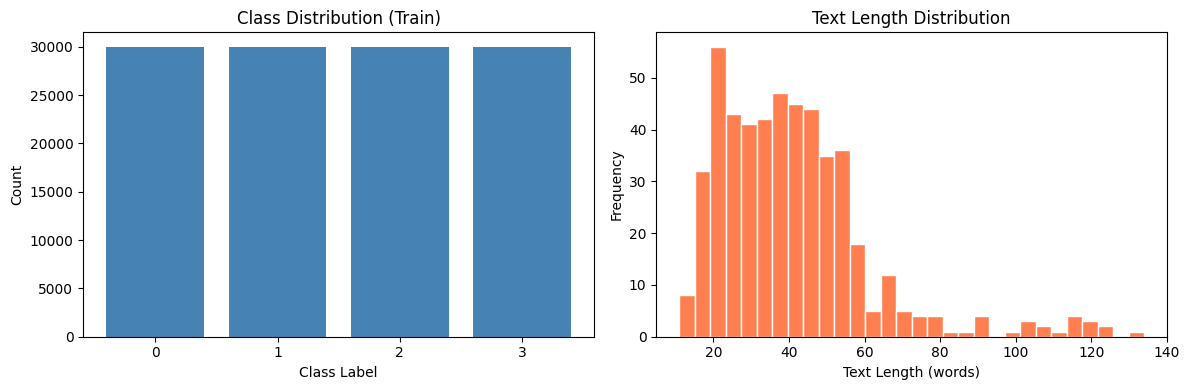

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [label for label, _ in train_data]
label_counts = Counter(labels)

axes[0].bar(
    label_counts.keys(),
    label_counts.values(),
    color='steelblue'
)

axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Train)')
axes[0].set_xticks([0, 1, 2, 3])

lengths = [
    len(text.split())
    for _, text in train_data[:500]
]

axes[1].hist(
    lengths,
    bins=30,
    color='coral',
    edgecolor='white'
)

axes[1].set_xlabel('Text Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Distribution')

plt.tight_layout()
plt.show()

In [7]:
print("\n=== Примеры ===")

for i in range(3):
    label, text = train_data[i]
    print(f"[Label {label}] {text[:150]}...")


=== Примеры ===
[Label 2] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....
[Label 2] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and ...
[Label 2] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expecte...


## 4. Токенизация и словарь

In [8]:
def tokenizer(text):
    """
    Простой токенизатор без torchtext.
    Приводит текст к нижнему регистру и отделяет пунктуацию.
    """
    return re.findall(
        r"\w+|[^\w\s]",
        text.lower()
    )


def yield_tokens(data):
    for _, text in data:
        yield tokenizer(text)

In [9]:
def build_vocab_from_iterator(iterator, min_freq=1):
    counter = Counter()

    for tokens in iterator:
        counter.update(tokens)

    # Индексы специальных токенов:
    # <pad> = 0
    # <unk> = 1
    vocab = {
        '<pad>': 0,
        '<unk>': 1,
    }

    frequent_tokens = [
        token
        for token, frequency in counter.items()
        if frequency >= min_freq
        and token not in ('<pad>', '<unk>')
    ]

    # Сначала частые слова, затем алфавитный порядок
    frequent_tokens.sort(
        key=lambda token: (-counter[token], token)
    )

    vocab.update({
        token: index
        for index, token in enumerate(
            frequent_tokens,
            start=2
        )
    })

    return vocab

In [10]:
# ============================================
# Задание 1: параметры построения словаря
# Попробуйте min_freq = 2 или 10. Как меняются размер словаря и качество модели?
# Почему редкие слова могут как помогать, так и мешать?
# ============================================
MIN_FREQ = 5  # <-- меняйте здесь

# Сначала строим словарь только из реальных токенов
vocab = build_vocab_from_iterator(
    yield_tokens(train_data),
    min_freq=MIN_FREQ
)

# Добавляем специальные токены вручную
# Порядок важен: <pad> должен быть первым (индекс 0), <unk> — вторым (индекс 1)

# Устанавливаем токен по умолчанию для неизвестных слов
PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

print(f"Размер словаря: {len(vocab)}")
print(f"PAD_IDX = {PAD_IDX}, UNK_IDX = {UNK_IDX}")

Размер словаря: 27831
PAD_IDX = 0, UNK_IDX = 1


## 5. Предобработка и Dataset

In [11]:
# ============================================
# Задание 2: длина последовательности (обрезка)
# Попробуйте MAX_LEN = 128, 256, 512. Как меняются скорость обучения и точность?
# Почему у RNN может не быть выигрыша от очень длинных последовательностей?
# ============================================
MAX_LEN = 256  # <-- меняйте здесь

In [12]:
def text_pipeline(text):
    tokens = tokenizer(text)

    ids = [
        vocab.get(token, UNK_IDX)
        for token in tokens
    ]

    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN]

    # На случай пустого текста
    if len(ids) == 0:
        ids = [UNK_IDX]

    return ids


def label_pipeline(label):
    return label

In [13]:
class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        data,
        text_pipeline,
        label_pipeline
    ):
        self.data = data
        self.text_pipeline = text_pipeline
        self.label_pipeline = label_pipeline

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label, text = self.data[idx]

        ids = self.text_pipeline(text)

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(
                self.label_pipeline(label),
                dtype=torch.long
            )
        )

In [14]:
def collate_batch(batch):
    text_list, label_list = zip(*batch)

    lengths = torch.tensor(
        [len(text) for text in text_list],
        dtype=torch.long
    )

    padded = pad_sequence(
        text_list,
        batch_first=True,
        padding_value=PAD_IDX
    )

    labels = torch.stack(label_list)

    return padded, lengths, labels

In [15]:
train_dataset = AGNewsDataset(
    train_data,
    text_pipeline,
    label_pipeline
)

test_dataset = AGNewsDataset(
    test_data,
    text_pipeline,
    label_pipeline
)

## 6. DataLoader

In [16]:
# ============================================
# Задание 3: размер батча
# Попробуйте BATCH_SIZE = 32, 64, 128. Как это влияет на стабильность обучения и скорость?
# Документация: https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader
# ============================================
BATCH_SIZE = 64  # <-- меняйте здесь

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(
    f"Количество батчей в обучении: "
    f"{len(train_loader)}"
)

Количество батчей в обучении: 1875


## 7. RNN-модель

In [18]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        rnn_output_dim = (
            hidden_dim * 2
            if bidirectional
            else hidden_dim
        )

        self.fc = nn.Linear(
            rnn_output_dim,
            num_classes
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        embedded = self.dropout(
            self.embedding(x)
        )

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        if self.rnn.bidirectional:
            last_hidden = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )
        else:
            last_hidden = hidden[-1]

        output = self.fc(
            self.dropout(last_hidden)
        )

        return output

In [19]:
# ============================================
# Задание 4: гиперпараметры модели
# Попробуйте разные комбинации и посмотрите на точность на валидации:
#   EMBED_DIM: 64, 128, 256
#   HIDDEN_DIM: 64, 128, 256
#   NUM_LAYERS: 1, 2
#   BIDIRECTIONAL: True / False
# Как размер скрытого состояния связан с числом параметров и качеством?
# ============================================
EMBED_DIM = 128       # <-- меняйте здесь
HIDDEN_DIM = 128      # <-- меняйте здесь
NUM_LAYERS = 1        # <-- меняйте здесь
BIDIRECTIONAL = False # <-- меняйте здесь (True/False)
DROPOUT = 0.2

In [20]:
model = RNNClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=4,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL
).to(device)

print(model)

print(
    f"Количество обучаемых параметров: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

RNNClassifier(
  (embedding): Embedding(27831, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Количество обучаемых параметров: 3,595,908


## 8. Обучение и проверка

In [21]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for texts, lengths, labels in tqdm(
        loader,
        desc="Training"
    ):
        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(texts, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        predictions = logits.argmax(dim=1)

        total_loss += (
            loss.item() * labels.size(0)
        )

        total_correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total_samples += labels.size(0)

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )

In [22]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, lengths, labels in tqdm(
            loader,
            desc="Evaluating"
        ):
            texts = texts.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            logits = model(texts, lengths)
            loss = criterion(logits, labels)

            predictions = logits.argmax(dim=1)

            total_loss += (
                loss.item() * labels.size(0)
            )

            total_correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            total_samples += labels.size(0)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        all_preds,
        all_labels
    )

In [23]:
# ============================================
# Задание 5: параметры оптимизатора
# Попробуйте LEARNING_RATE = 1e-3, 5e-4, 1e-4.
# Как скорость обучения влияет на сходимость и стабильность?
# Документация: https://pytorch.org/docs/stable/optim.html#torch.optim.Adam
# ============================================
LEARNING_RATE = 1e-3  # <-- меняйте здесь
NUM_EPOCHS = 5        # <-- меняйте здесь

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        test_loader,
        criterion
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Evaluating: 100%|██████████| 119/119 [00:00<00:00, 124.91it/s]


Epoch 1/5 | Train Loss: 0.8881 | Train Acc: 0.6220 | Val Loss: 0.6758 | Val Acc: 0.7532


Training:  42%|████▏     | 796/1875 [00:11<00:14, 76.64it/s]

## 9. Кривые обучения

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].plot(
    history['train_loss'],
    label='Train Loss',
    marker='o'
)

axes[0].plot(
    history['val_loss'],
    label='Val Loss',
    marker='s'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history['train_acc'],
    label='Train Acc',
    marker='o'
)

axes[1].plot(
    history['val_acc'],
    label='Val Acc',
    marker='s'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Матрица ошибок и classification report

In [ ]:
val_loss, val_acc, all_preds, all_labels = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Test loss: {val_loss:.4f}")
print(f"Test accuracy: {val_acc:.4f}")

In [ ]:
class_names = [
    'World',
    'Sports',
    'Business',
    'Sci/Tech'
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 11. Контрольные вопросы для студентов

1. **Почему в этом ноутбуке используется `pack_padded_sequence`?**  
   Что произойдёт, если убрать `pack_padded_sequence` и просто подать `padded` тензор в RNN?

2. **Как `min_freq` влияет на размер словаря и на количество параметров embedding-слоя?**  
   Оцените, как меняется число обучаемых параметров при `MIN_FREQ = 2` и `MIN_FREQ = 10`.

3. **Что означает `lengths.cpu()` в вызове `pack_padded_sequence`?**  
   Почему длины должны быть на CPU, а не на GPU?

4. **Почему при `BIDIRECTIONAL = True` используется `torch.cat([hidden[-2], hidden[-1]], dim=1)`?**  
   Что хранится в `hidden[-2]` и `hidden[-1]`?

5. **Как размер `HIDDEN_DIM` связан с числом параметров RNN?**  
   Выведите формулу для числа параметров `nn.RNN` (без bias и с bias).

6. **Почему `clip_grad_norm_` особенно важен для RNN?**  
   С каким явлением он борется?

7. **Что произойдёт, если `MAX_LEN` сделать очень большим (например, 2048)?**  
   Как это повлияет на время обучения, память и качество?

8. **Почему `padding_idx=PAD_IDX` важен в `nn.Embedding`?**  
   Что произойдёт, если его не указывать?

9. **Как интерпретировать матрицу ошибок?**  
   Какие классы чаще всего путаются и почему?

10. **Почему accuracy может быть не лучшей метрикой для этой задачи?**  
    Посмотрите на `classification_report` и объясните, какие метрики здесь информативнее.

## 12. Домашнее задание

### Часть A. Эксперименты с гиперпараметрами

Проведите **минимум 5 экспериментов**, меняя по одному гиперпараметру за раз:

1. `MIN_FREQ`: 2, 5, 10
2. `MAX_LEN`: 128, 256, 512
3. `BATCH_SIZE`: 32, 64, 128
4. `EMBED_DIM` / `HIDDEN_DIM`: (64, 64), (128, 128), (256, 256)
5. `NUM_LAYERS`: 1, 2
6. `BIDIRECTIONAL`: True / False
7. `LEARNING_RATE`: 1e-3, 5e-4, 1e-4

Для каждого эксперимента зафиксируйте:
- размер словаря;
- число параметров модели;
- время одной эпохи;
- `val_loss` и `val_acc` после 3–5 эпох.

Сведите результаты в таблицу и постройте графики зависимости `val_acc` от каждого гиперпараметра.

### Часть B. Анализ ошибок

1. Найдите **10 примеров**, на которых модель ошибается.
2. Для каждого примера укажите: истинный класс, предсказанный класс, текст (можно первые 200 символов).
3. Предложите **гипотезы**, почему модель ошибается (короткий текст, смешанная тематика, редкие слова и т.д.).
4. Предложите **2–3 идеи**, как улучшить модель именно на этих примерах.

### Часть C. Улучшение архитектуры

Замените `nn.RNN` на одну из архитектур:
- `nn.LSTM`
- `nn.GRU`
- двунаправленный LSTM/GRU

Сравните с базовой RNN по тем же метрикам. Объясните, почему LSTM/GRU часто работают лучше на длинных последовательностях.

### Часть D. Мини-исследование

Проверьте гипотезу: **«чем длиннее текст, тем лучше модель его классифицирует»**.

1. Разбейте тестовые примеры на группы по длине (например, 0–50, 51–100, 101–200, 200+ слов).
2. Посчитайте accuracy для каждой группы.
3. Постройте график зависимости accuracy от длины.
4. Сформулируйте вывод: подтверждается ли гипотеза?

### Формат сдачи

- Ноутбук `.ipynb` со всеми выполненными ячейками.
- Краткий отчёт (markdown внутри ноутбука): таблица экспериментов, графики, анализ ошибок, выводы.
- Ссылка на GitHub / Colab или сам файл.